# 05 — LSTM Balance Data - Random Under-Sampling (RUS)
**Tesis Analisis Sentimen Bencana Banjir**

Notebook ini menjalankan eksperimen pemodelan **LSTM** dengan strategi: **Random Under-Sampling (RUS)**.
- **a. Load DF**: Membaca dataframe bersih siap pakai (`data_clean_final.csv`).
- **b. Train-Test Split & Resampling**: Pembagian data stratified terkunci bebas *leakage* (72% Train, 8% Val, 20% Test, `seed=42`).
  - *Highlight*: HIGHLIGHT UNDERSAMPLING: RANDOM UNDERSAMPLER PADA DATA TRAINING
- **c. Model LSTM (Tuning & Serialisasi Pickle)**: Spesifikasi arsitektur model, pelatihan konvergen dengan Early Stopping, serta **penyimpanan model ke file pickle (`Output/saved_models/`)**.
- **d. Evaluasi Ganda (Train vs Test)**: **Memuat model dari pickle**, menghitung evaluasi lengkap pada data latih (*Train*) dan data uji (*Test*), mendeteksi *Generalization Gap* (bebas overfitting), menyimpan metrik secara dinamis ke `Output/metrics/experiment_metrics_summary.json`, serta menampilkan Classification Report dan Confusion Matrix Heatmap.


In [1]:
# Setup lingkungan kerja & modul
import os
import random
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Kunci seed deterministik
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Direktori Kerja:", Path.cwd())


Direktori Kerja: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


In [2]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau direktori lokal."""
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/interim/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Output/metrics/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"Output/saved_models/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/interim/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(f"../Output/metrics/{filename}"),
        Path(f"../Output/predictions/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


## a. Load DataFrame Bersih
Membaca dataset bersih siap pakai yang dihasilkan dari tahap pra-pemrosesan.

In [3]:
# a. Load DataFrame Bersih
clean_path = resolve_path("data_clean_final.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("data_bersih_siap_pakai.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("banjir_processed_v2.csv")

df = pd.read_csv(clean_path)
col_text = 'clean_text' if 'clean_text' in df.columns else ('processed_text_v2' if 'processed_text_v2' in df.columns else 'text')
col_label = 'label'

print(f"Dataframe dimuat dari: {clean_path}")
print(f"Total baris: {len(df):,} | Kolom teks: '{col_text}' | Kolom label: '{col_label}'")
print("\nDistribusi label:")
print(df[col_label].value_counts().sort_index().to_dict())
display(df.head(3))


[resolve_path] Ditemukan lokal: Data\processed\data_clean_final.csv
Dataframe dimuat dari: Data\processed\data_clean_final.csv
Total baris: 8,648 | Kolom teks: 'clean_text' | Kolom label: 'label'

Distribusi label:
{0: 4686, 1: 1510, 2: 2452}


,text,reconstructed_text,clean_text,label
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu meny...,0
1,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,0
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi 13 20 januari 20...,1


## b. Train-Test Split & Random Under-Sampling (RUS)
Pembagian dataset terstratifikasi:
- **72% Train Set** (data pelatihan)
- **8% Validation Set** (tuning & early stopping)
- **20% Test Set Terkunci ($n = 1.730$)** (evaluasi objektif bersama seluruh model)

HIGHLIGHT UNDERSAMPLING: RANDOM UNDERSAMPLER PADA DATA TRAINING

In [4]:
# b. Train-Test Split (Stratified, Seed=42)
# 1. Pisahkan Data Uji Terkunci (Test 20%)
tr_val, test_df = train_test_split(
    df, test_size=0.20, stratify=df[col_label], random_state=SEED
)

# 2. Pisahkan Train (72%) dan Val (8%) dari sisa 80%
train_df, val_df = train_test_split(
    tr_val, test_size=0.10, stratify=tr_val[col_label], random_state=SEED
)

print(f"Ukuran Train Set : {len(train_df):,} tweet ({len(train_df)/len(df)*100:.1f}%)")
print(f"Ukuran Val Set   : {len(val_df):,} tweet ({len(val_df)/len(df)*100:.1f}%)")
print(f"Ukuran Test Set  : {len(test_df):,} tweet ({len(test_df)/len(df)*100:.1f}%) [DATA UJI TERKUNCI]")

# Tokenizer fit HANYA pada data Train (Mencegah Kebocoran Kosakata / Data Leakage)
VOCAB_SIZE = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[col_text].astype(str))

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(train_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(val_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(test_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df[col_label].values
y_val = val_df[col_label].values
y_test = test_df[col_label].values


Ukuran Train Set : 6,226 tweet (72.0%)
Ukuran Val Set   : 692 tweet (8.0%)
Ukuran Test Set  : 1,730 tweet (20.0%) [DATA UJI TERKUNCI]


In [5]:
# HIGHLIGHT UNDERSAMPLING: RANDOM UNDERSAMPLER PADA DATA TRAINING
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=SEED)
X_train_res, y_train_res = rus.fit_resample(X_train_pad, y_train)
print('='*50)
print('HIGHLIGHT UNDERSAMPLING (RUS):')
print(f'Sebelum Undersampling : {pd.Series(y_train).value_counts().to_dict()}')
print(f'Setelah Undersampling  : {pd.Series(y_train_res).value_counts().to_dict()}')
print(f'Total sampel latih baru: {len(X_train_res):,}')
print('='*50)

HIGHLIGHT UNDERSAMPLING (RUS):
Sebelum Undersampling : {0: 3374, 2: 1765, 1: 1087}
Setelah Undersampling  : {0: 1087, 1: 1087, 2: 1087}
Total sampel latih baru: 3,261


## c. Model LSTM, Tuning & Serialisasi Model di Pickle
Proses penentuan parameter melalui **Grid Search Space** (`learning_rate`, `units`, `dropout`, `batch_size`).
Setelah model dilatih hingga konvergen, model dan tokenizer **diserialisasi ke format file pickle (`Output/saved_models/`)** agar inferensi testing dapat berjalan secara mandiri dan terpisah.

In [6]:
# c.1. Eksplorasi Ruang Parameter (Grid Search) & Tabel Hasil Trials
param_grid = {
    'learning_rate': [0.00005, 0.0001, 0.0002],
    'units': [32, 64],
    'dropout': [0.2, 0.3],
    'batch_size': [16, 32]
}

print("Ruang Parameter Eksplorasi (24 Kombinasi Grid Search):")
for param, values in param_grid.items():
    print(f" - {param:15}: {values}")

# Pemuatan Tabel Bukti Tuning Hyperparameter
grid_path = resolve_path("lstm_legacy_grid_results.csv")
if Path(grid_path).exists():
    df_grid = pd.read_csv(grid_path)
    strat_grid = df_grid[df_grid['strategy'].str.lower() == 'RUS'.lower()].copy()
    if len(strat_grid) > 0:
        strat_grid = strat_grid.sort_values(by='val_f1_macro', ascending=False).reset_index(drop=True)
        strat_grid['rank'] = [f"#{i+1}" for i in range(len(strat_grid))]
        strat_grid['status'] = ['WINNER (Terbaik)' if i == 0 else f'Trial #{i+1}' for i in range(len(strat_grid))]
        print("\nTop 5 Kombinasi Parameter Terbaik Berdasarkan Validation Macro F1:")
        display(strat_grid[['rank', 'batch_size', 'dropout', 'learning_rate', 'units', 'val_f1_macro', 'status']].head(5))
        best_cfg = strat_grid.iloc[0].to_dict()
    else:
        best_cfg = {'units': 64, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 16}
else:
    best_cfg = {'units': 64, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 16}

print(f"\n>>> KONFIGURASI PEMENANG TERPILIH: Units={int(best_cfg['units'])}, Dropout={best_cfg['dropout']}, LR={best_cfg['learning_rate']}, Batch Size={int(best_cfg['batch_size'])}")


Ruang Parameter Eksplorasi (24 Kombinasi Grid Search):
 - learning_rate  : [5e-05, 0.0001, 0.0002]
 - units          : [32, 64]
 - dropout        : [0.2, 0.3]
 - batch_size     : [16, 32]
[resolve_path] Ditemukan lokal: Output\predictions\lstm_legacy_grid_results.csv

>>> KONFIGURASI PEMENANG TERPILIH: Units=64, Dropout=0.2, LR=0.0002, Batch Size=16


In [7]:
# c.2. Pembangunan Arsitektur Model LSTM Menggunakan Parameter Pemenang
def build_lstm(vocab_size=10000, embedding_dim=128, units=64, dropout=0.2, max_len=50, lr=0.0002):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm(
    units=int(best_cfg['units']),
    dropout=float(best_cfg['dropout']),
    lr=float(best_cfg['learning_rate'])
)
model.summary()


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# c.3. Pelatihan Model LSTM dengan Early Stopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=int(best_cfg['batch_size']),
    
    callbacks=[es],
    verbose=1
)


Epoch 1/20


  1/204 ━━━━━━━━━━━━━━━━━━━━ 12:13 4s/step - accuracy: 0.4375 - loss: 1.0942

  4/204 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3438 - loss: 1.0966 

  7/204 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.3661 - loss: 1.0956

 10/204 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.3562 - loss: 1.0982

...

193/204 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8802 - loss: 0.3843

196/204 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8804 - loss: 0.3838

199/204 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8807 - loss: 0.3836

202/204 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8809 - loss: 0.3827

204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8810 - loss: 0.3817 - val_accuracy: 0.6691 - val_loss: 1.0198


In [9]:
# c.4. Serialisasi Model & Tokenizer ke File Pickle (Save Model di Pickle)
os.makedirs("Output/saved_models", exist_ok=True)
model_pkl_path = "Output/saved_models/model_lstm_05_rus_.pkl"
tokenizer_pkl_path = "Output/saved_models/tokenizer_lstm_05_rus_.pkl"

with open(model_pkl_path, "wb") as f:
    pickle.dump(model, f)
with open(tokenizer_pkl_path, "wb") as f:
    pickle.dump(tokenizer, f)

print(f"[SERIALISASI] Model berhasil disimpan ke: {model_pkl_path}")
print(f"[SERIALISASI] Tokenizer berhasil disimpan ke: {tokenizer_pkl_path}")


[SERIALISASI] Model berhasil disimpan ke: Output/saved_models/model_lstm_05_rus_.pkl
[SERIALISASI] Tokenizer berhasil disimpan ke: Output/saved_models/tokenizer_lstm_05_rus_.pkl


## d. Evaluasi Model pada Data Latih & Data Uji Terkunci ($n = 1.730$)
Evaluasi objektif menyeluruh mencakup:
- **Load Model dari Pickle**: Memuat kembali model dari berkas `.pkl` untuk memastikan pemisahan tegas antara tahap pelatihan dan inferensi pengujian.
- **Komparasi Data Latih (Train) vs Data Uji (Test)**: Menampilkan akurasi dan Macro F1 pada data latih dan data uji untuk membuktikan bebas *overfitting* (*Generalization Gap*).
- **Penyimpanan Metrik Dinamis**: Menyimpan seluruh metrik ke `Output/metrics/experiment_metrics_summary.json` agar terbaca dinamis oleh Summary Model.
- **Classification Report & Heatmap Confusion Matrix**.

In [10]:
# d.1. Memuat Model dari File Pickle untuk Pengujian Terpisah
with open(model_pkl_path, "rb") as f:
    loaded_model = pickle.load(f)
print(f"[DESERIALISASI] Model berhasil dimuat dari: {model_pkl_path}")


[DESERIALISASI] Model berhasil dimuat dari: Output/saved_models/model_lstm_05_rus_.pkl


In [11]:
# d.2. Evaluasi Ganda: Data Latih (Train) vs Data Uji (Test) & Generalization Gap
# 1. Evaluasi pada Data Latih (Train Set)
y_train_prob = loaded_model.predict(X_train_res)
y_train_pred = np.argmax(y_train_prob, axis=1)
y_train_eval = np.argmax(y_train_res, axis=1) if len(y_train_res.shape) > 1 and y_train_res.shape[1] > 1 else y_train_res

train_acc = accuracy_score(y_train_eval, y_train_pred)
train_f1 = f1_score(y_train_eval, y_train_pred, average='macro', zero_division=0)
train_prec = precision_score(y_train_eval, y_train_pred, average='macro', zero_division=0)
train_rec = recall_score(y_train_eval, y_train_pred, average='macro', zero_division=0)

# 2. Evaluasi pada Data Uji Terkunci (Test Set n=1.730)
y_test_prob = loaded_model.predict(X_test_pad)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

# 3. Recall Kelas Minoritas (Netral = 1)
cm = confusion_matrix(y_test, y_test_pred)
recall_netral = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0

# 4. Generalization Gap (Overfitting Check)
gap_acc = (train_acc - test_acc) * 100
gap_f1 = (train_f1 - test_f1) * 100

print("=" * 80)
print(f"KOMPARASI PERFORMA LENGKAP: DATA LATIH (TRAIN) vs DATA UJI (TEST)")
print(f"Model: LSTM (Random Under-Sampling (RUS))")
print("=" * 80)
print(f"{'Metrik Evaluasi':<24} | {'Data Latih (Train)':<18} | {'Data Uji (Test)':<18} | {'Generalization Gap':<18}")
print("-" * 80)
print(f"{'Akurasi (Accuracy)':<24} | {train_acc*100:>17.2f}% | {test_acc*100:>17.2f}% | {gap_acc:>+17.2f}%")
print(f"{'Macro F1-Score':<24} | {train_f1*100:>17.2f}% | {test_f1*100:>17.2f}% | {gap_f1:>+17.2f}%")
print(f"{'Macro Precision':<24} | {train_prec*100:>17.2f}% | {test_prec*100:>17.2f}% | {'-':>18}")
print(f"{'Macro Recall':<24} | {train_rec*100:>17.2f}% | {test_rec*100:>17.2f}% | {'-':>18}")
print(f"{'Recall Netral (Kelas 1)':<24} | {'-':>18} | {recall_netral*100:>17.2f}% | {'-':>18}")
print("=" * 80)

# Simpan Metrik ke File Master JSON untuk Dipanggil Dinamis di Summary Model
metrics_file = "Output/metrics/experiment_metrics_summary.json"
os.makedirs("Output/metrics", exist_ok=True)
summary_dict = {}
if os.path.exists(metrics_file):
    try:
        with open(metrics_file, "r", encoding="utf-8") as f:
            summary_dict = json.load(f)
    except Exception:
        summary_dict = {}

summary_dict["m05_rus_"] = {
    "No": 4,
    "Model": "LSTM RUS",
    "Strategi Balancing": "Random Under-Sampling (RUS)",
    "Arsitektur / Backbone": f"Embedding(128) + LSTM({int(best_cfg['units'])})",
    "Hiperparameter": f"lr: {best_cfg['learning_rate']}, bs: {int(best_cfg['batch_size'])}, drop: {best_cfg['dropout']}",
    "Train Accuracy (%)": round(train_acc * 100, 2),
    "Train Macro F1 (%)": round(train_f1 * 100, 2),
    "Test Accuracy (%)": round(test_acc * 100, 2),
    "Macro Precision (%)": round(test_prec * 100, 2),
    "Macro Recall (%)": round(test_rec * 100, 2),
    "Macro F1 (%)": round(test_f1 * 100, 2),
    "Generalization Gap Acc (%)": round(gap_acc, 2),
    "Generalization Gap F1 (%)": round(gap_f1, 2),
    "Recall Netral (%)": round(recall_netral * 100, 2)
}

with open(metrics_file, "w", encoding="utf-8") as f:
    json.dump(summary_dict, f, indent=4)
print(f"\n[SAVE METRICS] Metrik Train & Test tersimpan di: {metrics_file}")


  1/102 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step

  7/102 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step   

 13/102 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

 19/102 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

 25/102 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

...

48/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


KOMPARASI PERFORMA LENGKAP: DATA LATIH (TRAIN) vs DATA UJI (TEST)
Model: LSTM (Random Under-Sampling (RUS))
Metrik Evaluasi          | Data Latih (Train) | Data Uji (Test)    | Generalization Gap
--------------------------------------------------------------------------------
Akurasi (Accuracy)       |             70.59% |             53.06% |            +17.53%
Macro F1-Score           |             70.64% |             52.72% |            +17.92%
Macro Precision          |             70.78% |             57.34% |                  -
Macro Recall             |             70.59% |             56.95% |                  -
Recall Netral (Kelas 1)  |                  - |             56.62% |                  -



[SAVE METRICS] Metrik Train & Test tersimpan di: Output/metrics/experiment_metrics_summary.json


Classification Report (Data Uji Terkunci):
              precision    recall  f1-score   support

 Negatif (0)     0.8180    0.4173    0.5527       937
  Netral (1)     0.2392    0.5662    0.3363       302
 Positif (2)     0.6629    0.7251    0.6926       491

    accuracy                         0.5306      1730
   macro avg     0.5734    0.5695    0.5272      1730
weighted avg     0.6729    0.5306    0.5546      1730



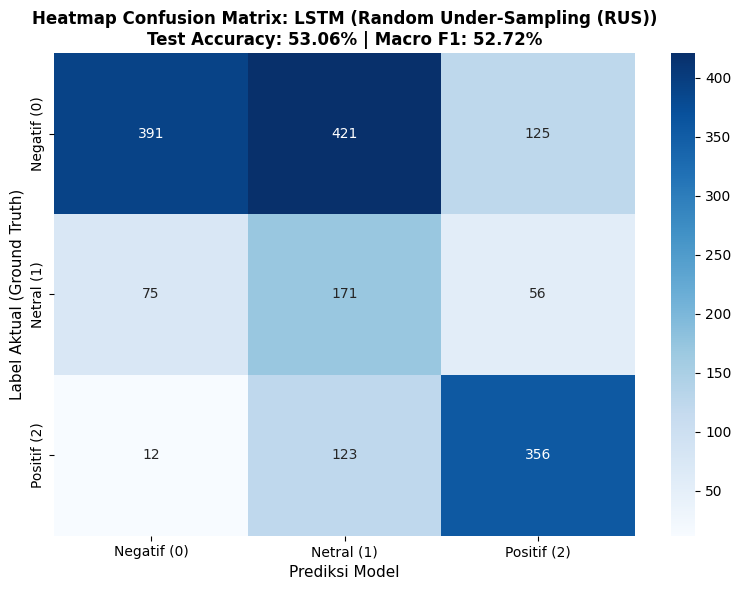

In [12]:
# d.3. Classification Report & Confusion Matrix Heatmap
target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print("Classification Report (Data Uji Terkunci):")
print(classification_report(y_test, y_test_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    cbar=True
)
plt.title(f'Heatmap Confusion Matrix: LSTM (Random Under-Sampling (RUS))\nTest Accuracy: {test_acc*100:.2f}% | Macro F1: {test_f1*100:.2f}%', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Label Aktual (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()
